## Libraries

In [1]:
import os
import warnings 
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression     
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import VotingClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score, roc_curve, auc

# import pytorch_lightning as pl
# import torch
# import torch.nn as nn
# import torch.optim as optim
# import torch.nn.functional as F

import shap

## Data import

- from Kaggle (https://www.kaggle.com/datasets/kartik2112/fraud-detection)

In [2]:
train = pd.read_csv('dataset/fraud_train.csv')
test = pd.read_csv('dataset/fraud_test.csv')

train.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


인덱스였던 column `'Unnamed: 0'`은 의미가 없으므로 drop

In [3]:
train.drop(columns=['Unnamed: 0'], inplace=True)
test.drop(columns=['Unnamed: 0'], inplace=True)

## Data concat

In [4]:
print(train.shape, test.shape)

(1296675, 22) (555719, 22)


In [5]:
data = pd.concat([train, test], axis=0)
data.reset_index(drop=True, inplace=True)
data.shape

(1852394, 22)

## Feature Engineering

- `'lat'`, `'long'` 지우기
- `'amount'`는 상대적으로 중요한 정보가 될 수 있다고 판단
- `'cc_num'`은 사람과 연결되는 정보로 연결하여 카테고리화

### 1. some geometric info drop

In [6]:
data = data.drop(columns=['lat', 'long'])

### 2. datetime 데이터 타입 변경 및 `'unix_time'` drop


In [7]:
# data = data.drop(columns=['unix_time'])
data = data.astype({'trans_date_trans_time': 'datetime64[ns]', 'dob': 'datetime64[ns]'})

In [8]:
data['trans_date_trans_time'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1852394 entries, 0 to 1852393
Series name: trans_date_trans_time
Non-Null Count    Dtype         
--------------    -----         
1852394 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 14.1 MB


### 3. `'trans_num'`, time 관련 drop
변덕..

In [9]:
###  data['trans_num'].nunique() = 1852394
data = data.drop(columns=['trans_num', 'trans_date_trans_time', 'dob'])

In [10]:
# 컬럼들을 범주형으로 변환
for col in data.select_dtypes(include=['object']).columns:
    data[col] = data[col].astype('category')

# 추가로 zip code와 cc_num 컬럼도 변환
data['zip'] = data['zip'].astype('category')
data['cc_num'] = data['cc_num'].astype('category')

📌

- 사람 정보는 이름만 엮어서 한 컬럼으로 만든 뒤 사용
    - 후에 성능을 확인하면서 최종 사용 여부 정하기

# train-test-split

In [11]:
num_train = len(train)
target_column = data['is_fraud'].copy()

X = data.iloc[:num_train].drop(columns=['is_fraud'])
X_test = data.iloc[num_train:].drop(columns=['is_fraud'])

y = target_column.iloc[:num_train].values
y_test = target_column.iloc[num_train:].values

In [12]:
print(X.shape, X_test.shape)
print(y.shape, y_test.shape)

(1296675, 16) (555719, 16)
(1296675,) (555719,)


# Baseline

- model: LightGBM, OOF 방식
- evaluation: eval-Gini

In [13]:
import numpy as np

def eval_gini(y_true, y_pred):
    # 실제값과 예측값의 크기가 같은지 확인 (값이 다르면 오류 발생)
    assert y_true.shape == y_pred.shape

    n_samples = y_true.shape[0]                      # 데이터 개수
    L_mid = np.linspace(1 / n_samples, 1, n_samples) # 대각선 값

    # 1) 예측값에 대한 지니계수
    pred_order = y_true[y_pred.argsort()] # y_pred 크기순으로 y_true 값 정렬
    L_pred = np.cumsum(pred_order) / np.sum(pred_order) # 로렌츠 곡선
    G_pred = np.sum(L_mid - L_pred)       # 예측 값에 대한 지니계수

    # 2) 예측이 완벽할 때 지니계수
    true_order = y_true[y_true.argsort()] # y_true 크기순으로 y_true 값 정렬
    L_true = np.cumsum(true_order) / np.sum(true_order) # 로렌츠 곡선
    G_true = np.sum(L_mid - L_true)       # 예측이 완벽할 때 지니계수

    # 정규화된 지니계수
    return G_pred / G_true

In [14]:
def gini(preds, dtrain):
    labels = dtrain.get_label()
    return 'gini', eval_gini(labels, preds), True # 반환값

In [15]:
from sklearn.model_selection import StratifiedKFold

# 층화 K 폴드 교차 검증기
folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=617)

In [16]:
folds.split(X, y)

<generator object _BaseKFold.split at 0x0000011C4A345460>

In [17]:
# 검증 데이터 타깃값을 예측한 확률을 담을 1차원 배열
oof_val_preds = np.zeros(X.shape[0]) 
# 테스트 데이터 타깃값을 예측한 확률을 담을 1차원 배열
oof_test_preds = np.zeros(X_test.shape[0]) 

In [18]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

# Gini 계수 평가 함수
# def eval_gini(y_true, y_pred):
#     return 2 * roc_auc_score(y_true, y_pred) - 1

# 하이퍼파라미터 설정
params = {
    'objective': 'binary',
    'metric': 'gini',
    'boosting_type': 'gbdt',
    'learning_rate': 0.01,
    'num_leaves': 31,
    'max_depth': -1,
    'seed': 42,
    'n_jobs': -1,
    'verbose': -1,
}

# 폴드 설정
n_splits = 5
folds = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=617)

# OOF 예측을 저장할 배열 초기화
oof_val_preds = np.zeros(len(X))
oof_test_preds = np.zeros(len(X_test))

# 폴드별 훈련 및 예측
for idx, (train_idx, valid_idx) in enumerate(folds.split(X, y)):
    print('#'*40, f'폴드 {idx+1} / 폴드 {folds.n_splits}', '#'*40)

    # 훈련용, 검증용 데이터 설정
    X_train, y_train = X.iloc[train_idx], y[train_idx] # X는 DataFrame이므로 .iloc 사용
    X_valid, y_valid = X.iloc[valid_idx], y[valid_idx] # X는 DataFrame이므로 .iloc 사용

    # y가 NumPy 배열이므로 직접 인덱싱
    y_train = y[train_idx]
    y_valid = y[valid_idx]

    # LightGBM 전용 데이터셋 생성
    dtrain = lgb.Dataset(X_train, y_train)
    dvalid = lgb.Dataset(X_valid, y_valid)

    # LightGBM 모델 훈련
    callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=-1),
           lgb.log_evaluation(period=100)] # 100번째마다 로그 출력

    lgb_model = lgb.train(params=params,
                            train_set=dtrain,
                            num_boost_round=1000,
                            valid_sets=dvalid,
                            feval=gini, # 베이스라인의 gini 함수를 eval_gini로 변경
                            callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=-1)]
                            )

    # 테스트 데이터 예측 및 OOF 누적
    oof_test_preds += lgb_model.predict(X_test) / folds.n_splits

    # 검증 데이터 예측 및 OOF 저장
    oof_val_preds[valid_idx] = lgb_model.predict(X_valid)

    # 검증 데이터 지니 계수 평가
    gini_score = eval_gini(y_valid, oof_val_preds[valid_idx])
    print(f'폴드 {idx+1} 지니계수 : {gini_score}\n')

# 최종 OOF 검증 지니 계수 평가
oof_gini_score = eval_gini(y, oof_val_preds)
print(f'최종 OOF 지니계수 : {oof_gini_score}')

# oof_test_preds (테스트 데이터 OOF 예측 결과) 와 oof_val_preds (검증 데이터 OOF 예측 결과) 를 사용할 수 있습니다.

######################################## 폴드 1 / 폴드 5 ########################################
Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[1000]	valid_0's gini: 0.989988
폴드 1 지니계수 : 0.9899875515503089

######################################## 폴드 2 / 폴드 5 ########################################
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[756]	valid_0's gini: 0.987484
폴드 2 지니계수 : 0.9874842133448561

######################################## 폴드 3 / 폴드 5 ########################################
Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[998]	valid_0's gini: 0.987933
폴드 3 지니계수 : 0.9879326423851088

######################################## 폴드 4 / 폴드 5 ########################################
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[503]	valid_0's gini

# FE1


### 이름은 묶어서 처리

In [19]:
data = pd.concat([train, test], axis=0)
data.reset_index(drop=True, inplace=True)

df = data.copy()  
df['name'] = df['first'].astype(str) + ' ' + df['last'].astype(str)
df = df.drop(columns=['first', 'last'])
df.head(3)

,trans_date_trans_time,cc_num,merchant,category,amt,gender,street,city,state,zip,...,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,name
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,561 Perry Cove,Moravian Falls,NC,28654,...,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,Jennifer Banks
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,43039 Riley Greens Suite 393,Orient,WA,99160,...,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,Stephanie Gill
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,M,594 White Dale Suite 530,Malad City,ID,83252,...,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,Edward Sanchez


### cc_num, zip : int -> `astype(category)`
대부분의 컬럼을 범주형으로 변환

In [20]:
# 컬럼들을 범주형으로 변환
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].astype('category')

# 추가로 zip code와 cc_num 컬럼도 변환
df['zip'] = df['zip'].astype('category')
df['cc_num'] = df['cc_num'].astype('category')

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1852394 entries, 0 to 1852393
Data columns (total 21 columns):
 #   Column                 Dtype   
---  ------                 -----   
 0   trans_date_trans_time  category
 1   cc_num                 category
 2   merchant               category
 3   category               category
 4   amt                    float64 
 5   gender                 category
 6   street                 category
 7   city                   category
 8   state                  category
 9   zip                    category
 10  lat                    float64 
 11  long                   float64 
 12  city_pop               int64   
 13  job                    category
 14  dob                    category
 15  trans_num              category
 16  unix_time              int64   
 17  merch_lat              float64 
 18  merch_long             float64 
 19  is_fraud               int64   
 20  name                   category
dtypes: category(13), float64(5), in

# Baseline 시도1

#### train-test-split

In [22]:
num_train = len(train)
target_column = df['is_fraud'].copy()

X = df.iloc[:num_train].drop(columns=['is_fraud'])
X_test = df.iloc[num_train:].drop(columns=['is_fraud'])

y = target_column.iloc[:num_train].values
y_test = target_column.iloc[num_train:].values

In [23]:
print(X.shape, X_test.shape) # name 두 컬럼이 한 컬럼으로 들어가 줄었음음
print(y.shape, y_test.shape)

(1296675, 20) (555719, 20)
(1296675,) (555719,)


In [24]:
oof_val_preds = np.zeros(X.shape[0]) 
oof_test_preds = np.zeros(X_test.shape[0]) 

In [25]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

# def eval_gini(y_true, y_pred):
#     return 2 * roc_auc_score(y_true, y_pred) - 1

params = {
    'objective': 'binary',
    'metric': 'gini',
    'boosting_type': 'gbdt',
    'learning_rate': 0.01,
    'num_leaves': 31,
    'max_depth': -1,
    'seed': 42,
    'n_jobs': -1,
    'verbose': -1,
}

# 폴드 설정
n_splits = 5
folds = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=617)

# OOF 예측을 저장할 배열 초기화
oof_val_preds = np.zeros(len(X))
oof_test_preds = np.zeros(len(X_test))

# 폴드별 훈련 및 예측
for idx, (train_idx, valid_idx) in enumerate(folds.split(X, y)):
    print('#'*40, f'폴드 {idx+1} / 폴드 {folds.n_splits}', '#'*40)

    # 훈련용, 검증용 데이터 설정
    X_train, y_train = X.iloc[train_idx], y[train_idx] # X는 DataFrame이므로 .iloc 사용
    X_valid, y_valid = X.iloc[valid_idx], y[valid_idx] # X는 DataFrame이므로 .iloc 사용

    # y가 NumPy 배열이므로 직접 인덱싱
    y_train = y[train_idx]
    y_valid = y[valid_idx]

    # LightGBM 전용 데이터셋 생성
    dtrain = lgb.Dataset(X_train, y_train)
    dvalid = lgb.Dataset(X_valid, y_valid)

    # LightGBM 모델 훈련
    callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=-1),
           lgb.log_evaluation(period=100)] # 100번째마다 로그 출력

    lgb_model = lgb.train(params=params,
                            train_set=dtrain,
                            num_boost_round=1000,
                            valid_sets=dvalid,
                            feval=gini, # 베이스라인의 gini 함수를 eval_gini로 변경
                            callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=-1)]
                            )

    # 테스트 데이터 예측 및 OOF 누적
    oof_test_preds += lgb_model.predict(X_test) / folds.n_splits

    # 검증 데이터 예측 및 OOF 저장
    oof_val_preds[valid_idx] = lgb_model.predict(X_valid)

    # 검증 데이터 지니 계수 평가
    gini_score = eval_gini(y_valid, oof_val_preds[valid_idx])
    print(f'폴드 {idx+1} 지니계수 : {gini_score}\n')

# 최종 OOF 검증 지니 계수 평가
oof_gini_score = eval_gini(y, oof_val_preds)
print(f'최종 OOF 지니계수 : {oof_gini_score}')

######################################## 폴드 1 / 폴드 5 ########################################
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[533]	valid_0's gini: 0.989626
폴드 1 지니계수 : 0.9896255908204926

######################################## 폴드 2 / 폴드 5 ########################################
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[658]	valid_0's gini: 0.987622
폴드 2 지니계수 : 0.987621533207689

######################################## 폴드 3 / 폴드 5 ########################################
Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[1000]	valid_0's gini: 0.988308
폴드 3 지니계수 : 0.9883084064174101

######################################## 폴드 4 / 폴드 5 ########################################
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[456]	valid_0's gini: 0.988835
폴드 

#### 일반 lightgbm 단일 모델의 경우

In [26]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# 데이터 분리
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=617, stratify=y)

# LightGBM 모델 훈련
params_lgb = {
    'objective': 'binary',
    'metric': 'auc', # LightGBM 내부 평가 지표
    'boosting_type': 'gbdt',
    'n_estimators': 1000, # 부스팅 반복 횟수 (num_boost_round 대신 n_estimators 사용)
    'learning_rate': 0.01,
    'num_leaves': 31,
    'max_depth': -1,
    'seed': 617,
    'n_jobs': -1,
    'verbose': -1,
    'colsample_bytree': 0.7, # 추가 파라미터 예시
    'subsample': 0.7,        # 추가 파라미터 예시
    'reg_alpha': 0.1,        # 추가 파라미터 예시
    'reg_lambda': 0.1        # 추가 파라미터 예시
}

print("### LightGBM 모델 훈련 시작 ###")

# LightGBM 전용 데이터셋 생성
dtrain = lgb.Dataset(X_train, y_train)
dvalid = lgb.Dataset(X_valid, y_valid)

lgb_model = lgb.train(
    params=params_lgb,
    train_set=dtrain,
    valid_sets=dvalid,
    feval=gini, # 검증용 평가지표 (사용자 정의 함수)
    callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False),
               lgb.log_evaluation(period=100)] # 100번째마다 로그 출력
)

# 예측 및 평가
# 검증 데이터 예측
valid_preds_lgb = lgb_model.predict(X_valid, num_iteration=lgb_model.best_iteration)
gini_score_lgb = eval_gini(y_valid, valid_preds_lgb)
print(f'\nLightGBM 검증 지니계수: {gini_score_lgb}')

# 테스트 데이터 예측
test_preds_lgb = lgb_model.predict(X_test, num_iteration=lgb_model.best_iteration)

print("\nLightGBM 모델 훈련 및 예측 완료.")

### LightGBM 모델 훈련 시작 ###
[100]	valid_0's auc: 0.978074	valid_0's gini: 0.956147
[200]	valid_0's auc: 0.98551	valid_0's gini: 0.971019
[300]	valid_0's auc: 0.990403	valid_0's gini: 0.980807
[400]	valid_0's auc: 0.992397	valid_0's gini: 0.984795
[500]	valid_0's auc: 0.993295	valid_0's gini: 0.98659
[600]	valid_0's auc: 0.993658	valid_0's gini: 0.987315
[700]	valid_0's auc: 0.994034	valid_0's gini: 0.988068
[800]	valid_0's auc: 0.994113	valid_0's gini: 0.988226
[900]	valid_0's auc: 0.994511	valid_0's gini: 0.989022
[1000]	valid_0's auc: 0.994634	valid_0's gini: 0.989269

LightGBM 검증 지니계수: 0.9892734644915109

LightGBM 모델 훈련 및 예측 완료.


📌
- 과적합에 가까운 점수인데 그렇다면 실제값 즉 y_test은 얼마나 잘 맞추는가?

In [27]:
fianl_gini_score_lgb = eval_gini(y_test, test_preds_lgb)
print(f'\nLightGBM 최종 지니계수: {fianl_gini_score_lgb}')


LightGBM 최종 지니계수: 0.9358091543013524


📌
- 이정도면 적당히 괜찮다는 생각이 든다. 
    - 하지만 여전히 is_fraud = 1인 값이 매우 희소하기 때문에 ()= 0 인 값만 맞춰도 점수는 올라가는 문제가 있음)

- 미탐은 위험하고 오탐도 중요할 때...
    - Precision, recall, F1-Score...

# Baseline 시도2(평가지표 변경 및 Booster 객체에서 표준 메서드로 변경)

In [28]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, roc_auc_score 
from sklearn.preprocessing import Binarizer 

# Assume X, y, X_test are already defined

# 데이터 분리
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=617, stratify=y)

# Custom F1-score evaluation function for LightGBM
def f1_eval(y_pred, train_data):
    y_true = train_data.get_label()
    # Apply a threshold (e.g., 0.5) to convert probabilities to binary predictions
    y_pred_binary = (y_pred >= 0.5).astype(int)
    return 'f1_score', f1_score(y_true, y_pred_binary), True # True means higher is better

# LightGBM 모델 훈련
params_lgb = {
    'objective': 'binary', # Keep as binary for classification
    'metric': 'auc', # LightGBM internal evaluation metric (can be auc or binary_logloss)
    'boosting_type': 'gbdt',
    'n_estimators': 1000,
    'learning_rate': 0.01,
    'num_leaves': 31,
    'max_depth': -1,
    'seed': 617,
    'n_jobs': -1,
    'verbose': -1,
    'colsample_bytree': 0.7,
    'subsample': 0.7,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1
}

print("### LightGBM 모델 훈련 시작 ###")

# LightGBM 전용 데이터셋 생성
dtrain = lgb.Dataset(X_train, y_train)
dvalid = lgb.Dataset(X_valid, y_valid)

lgb_model_f1 = lgb.train(
    params=params_lgb,
    train_set=dtrain,
    valid_sets=dvalid,
    feval=f1_eval, # Use the custom F1-score evaluation function
    callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False),
               lgb.log_evaluation(period=100)]
)

# 예측 및 평가
# 검증 데이터 예측
valid_preds_lgb = lgb_model_f1.predict(X_valid, num_iteration=lgb_model_f1.best_iteration)
# Convert probabilities to binary predictions for F1-score calculation
valid_preds_lgb_binary = (valid_preds_lgb >= 0.5).astype(int)
f1_score_lgb = f1_score(y_valid, valid_preds_lgb_binary)
print(f'\nLightGBM 검증 F1-score: {f1_score_lgb}')

# 테스트 데이터 예측
test_preds_lgb = lgb_model_f1.predict(X_test, num_iteration=lgb_model_f1.best_iteration)
# For final test predictions, you might also want to convert to binary if F1-score is the ultimate goal
test_preds_lgb_binary = (test_preds_lgb >= 0.5).astype(int)

print("\nLightGBM 모델 훈련 및 예측 완료.")

### LightGBM 모델 훈련 시작 ###
[100]	valid_0's auc: 0.978074	valid_0's f1_score: 0.222617
[200]	valid_0's auc: 0.98551	valid_0's f1_score: 0.592928
[300]	valid_0's auc: 0.990403	valid_0's f1_score: 0.689376
[400]	valid_0's auc: 0.992397	valid_0's f1_score: 0.709475
[500]	valid_0's auc: 0.993295	valid_0's f1_score: 0.714506
[600]	valid_0's auc: 0.993658	valid_0's f1_score: 0.720554
[700]	valid_0's auc: 0.994034	valid_0's f1_score: 0.72804
[800]	valid_0's auc: 0.994113	valid_0's f1_score: 0.729239
[900]	valid_0's auc: 0.994511	valid_0's f1_score: 0.736883
[1000]	valid_0's auc: 0.994634	valid_0's f1_score: 0.737819

LightGBM 검증 F1-score: 0.7385924207269915

LightGBM 모델 훈련 및 예측 완료.


In [29]:
fianl_f1_score_lgb = f1_score(y_test, test_preds_lgb_binary)
final_auc_score_lgb = roc_auc_score(y_test, test_preds_lgb)
print(f'\nLightGBM 최종 f1-score: {fianl_f1_score_lgb}')
print(f'LightGBM 최종 ROC AUC: {final_auc_score_lgb}')


LightGBM 최종 f1-score: 0.328135593220339
LightGBM 최종 ROC AUC: 0.9679045784139232


In [32]:
########################## 변경

import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, roc_auc_score 

# 데이터 분리
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=617, stratify=y)

# LightGBM 모델 파라미터
params_lgb = {
    'objective': 'binary', # 이진 분류
    'metric': 'f1_score',  # f1score
    'boosting_type': 'gbdt',
    'n_estimators': 1000,
    'learning_rate': 0.01,
    'num_leaves': 31,
    'max_depth': -1,
    'random_state': 617,
    'n_jobs': -1,
    'verbose': -1,
    'colsample_bytree': 0.7,
    'subsample': 0.7,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1
}

print("### LightGBM 모델 훈련 시작 (LGBMClassifier) ###")

lgb_model_f1_st = lgb.LGBMClassifier(**params_lgb)

lgb_model_f1_st.fit(X_train, y_train,
                 eval_set=[(X_valid, y_valid)], # 검증셋
                 eval_metric='auc', 
                 callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False),
                            lgb.log_evaluation(period=100)]
                )

# 예측 및 평가
# 검증 데이터 예측
valid_preds_lgb = lgb_model_f1_st.predict_proba(X_valid)[:, 1] # 클래스 1에 대한 확률만 추출

#  Convert probabilities to binary predictions for F1-score calculation
valid_preds_lgb_binary = (valid_preds_lgb >= 0.5).astype(int)
f1_score_lgb_st = f1_score(y_valid, valid_preds_lgb_binary)
auc_score_lgb_st = roc_auc_score(y_valid, valid_preds_lgb)

print(f'\nLightGBM 검증 F1-score: {f1_score_lgb_st}')
print(f'LightGBM 검증 ROC AUC: {roc_auc_score(y_valid, valid_preds_lgb)}')

# 테스트 데이터 예측
# predict_proba는 확률을 반환
test_preds_lgb_st = lgb_model_f1_st.predict_proba(X_test)[:, 1]

# For final test predictions, you might also want to convert to binary if F1-score is the ultimate goal
test_preds_lgb_binary_st = (test_preds_lgb_st >= 0.5).astype(int)

print("\nLightGBM 모델 훈련 및 예측 완료 (LGBMClassifier).")

### LightGBM 모델 훈련 시작 (LGBMClassifier) ###
[100]	valid_0's auc: 0.978074
[200]	valid_0's auc: 0.98551
[300]	valid_0's auc: 0.990403
[400]	valid_0's auc: 0.992397
[500]	valid_0's auc: 0.993295
[600]	valid_0's auc: 0.993658
[700]	valid_0's auc: 0.994034
[800]	valid_0's auc: 0.994113
[900]	valid_0's auc: 0.994511
[1000]	valid_0's auc: 0.994634

LightGBM 검증 F1-score: 0.7385924207269915
LightGBM 검증 ROC AUC: 0.9946367322457554

LightGBM 모델 훈련 및 예측 완료 (LGBMClassifier).


In [33]:
fianl_f1_score_lgb_st = f1_score(y_test, test_preds_lgb_binary_st)
final_auc_score_lgb_st = roc_auc_score(y_test, test_preds_lgb_st)
print(f'\nLightGBM 최종 f1-score: {fianl_f1_score_lgb_st}')
print(f'LightGBM 최종 ROC AUC: {final_auc_score_lgb_st}')


LightGBM 최종 f1-score: 0.328135593220339
LightGBM 최종 ROC AUC: 0.9679045784139232


📌
- 과적합이 보임
- 일단 모델로 시각화를 시도하기로 결정
    - 추후에 transaction time을 년월일시로 나누어서 피처로 사용하는 방법도 고려해볼 수 있을 것으로 생각

# Visualization

## 1. feature importance

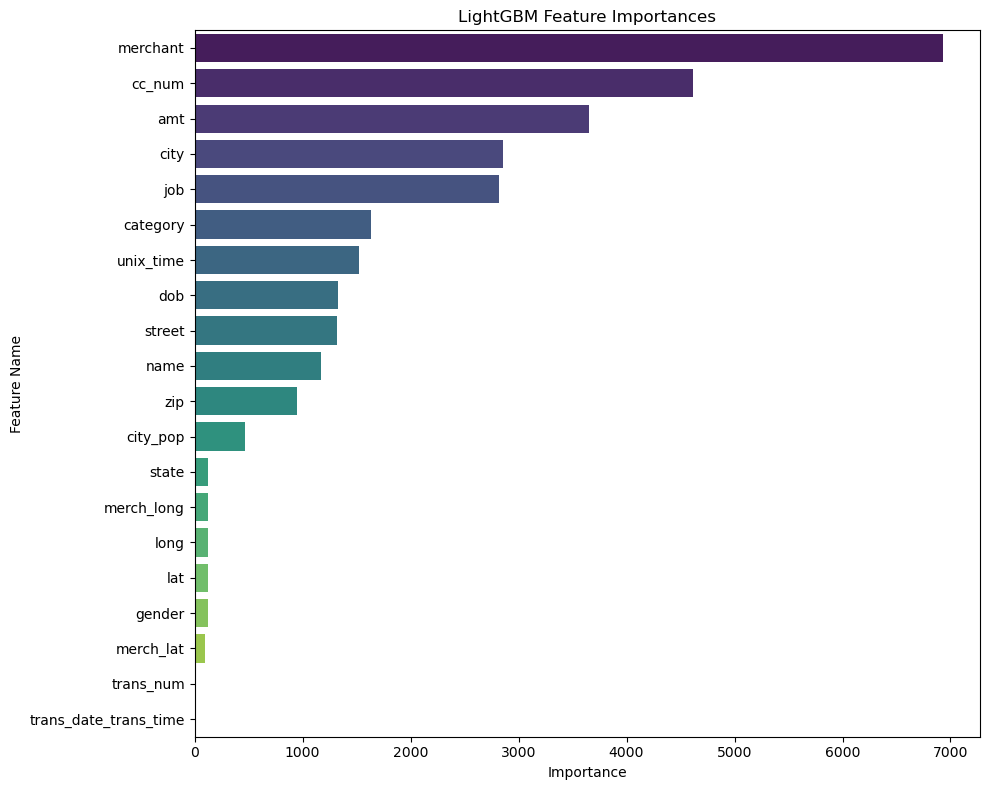


상위 특성 중요도:
      feature  importance
2    merchant        6927
1      cc_num        4613
4         amt        3650
7        city        2860
13        job        2821
3    category        1637
16  unix_time        1519
14        dob        1329
6      street        1319
19       name        1168


In [34]:
feature_importances = lgb_model_f1_st.feature_importances_ # 또는 'gain'
feature_names = X_train.columns

# 중요도를 데이터프레임으로 만들고 정렬
importance_df = pd.DataFrame({'feature': feature_names, 'importance': feature_importances})
importance_df = importance_df.sort_values(by='importance', ascending=False)

# 상위 N개 특성만 시각화 (선택 사항)
top_n = 20 # 예를 들어 상위 20개만
if len(importance_df) > top_n:
    importance_df_display = importance_df.head(top_n)
else:
    importance_df_display = importance_df

plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=importance_df_display, palette='viridis')
plt.title('LightGBM Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

print("\n상위 특성 중요도:")
print(importance_df.head(10)) # 상위 10개 출력

📌
- merchant가 중요 : 사기치는 판매자는 사기를 계속 치는것인가!
- cc_num : 의외로 중요한 이유는 뭘까? 사기를 당한 사람이 계속 당한걸까?
- amt : 특정 금액이 있나?
- job, city : user의 정보인데 중요한 것으로 나왔음, job은 처리가 안된 상태로 거의 사람별 고유한 상태라 cc_num과 맥락을 같이한다고 볼 수 있을지도.
- gender는 중요하지 않음


In [35]:
df['job'].nunique(), df['name'].nunique()

(497, 989)

## 2. 특정 피처가 예측값에 미치는 영향

- 예측값이 binary 분류 
- 실제 '수'로써 시각화하는 것은 'amt' 컬럼으로 해보기로 

In [ ]:
# from interpret import set_visualize_provider
# from interpret.provider import InlineProvider
# set_visualize_provider(InlineProvider())

# import numpy as np
# from sklearn.model_selection import train_test_split

# from sklearn.ensemble import RandomForestRegressor
# from sklearn.decomposition import PCA
# from sklearn.pipeline import Pipeline

# from interpret import show
# from interpret.blackbox import PartialDependence


# # Plotting PDP plot ----

# # 숫자타입만만
# numeric_columns = X_train.select_dtypes(include=['float64', 'int64']).columns
# # print("Numeric columns:", numeric_columns.tolist())

# # Partial Dependence Plot for numeric features
# pdp = PartialDependence(lgb_model_f1_st, X_train[numeric_columns])
# show(pdp.explain_global(), 0)

# show(pdp.explain_global(), 0)

ValueError: Number of features of the model must match the input. Model n_features_ is 20 and input n_features is 7

### ICE plot 그려보기

예측값까지 데이터포인트들의 발자취,,,

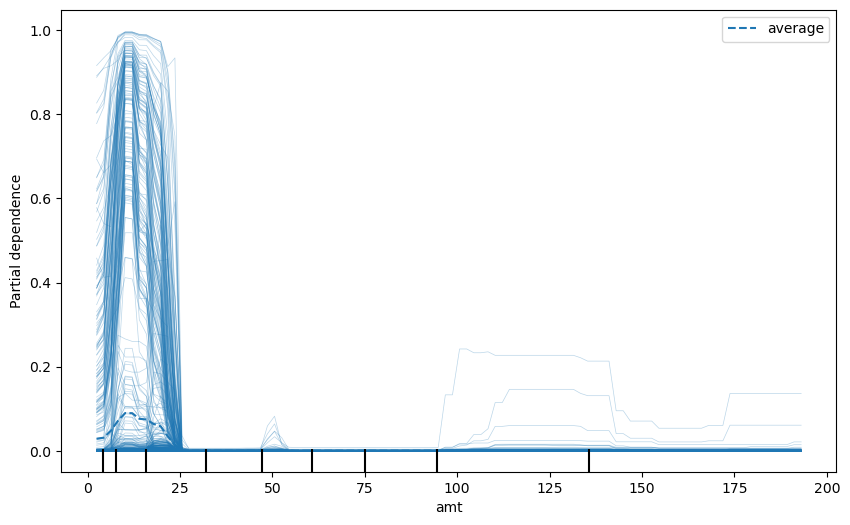

In [ ]:
import pandas as pd
import numpy as np

from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# Create ICE plot : 'amt' feature
fig, ax = plt.subplots(figsize=(10, 6))
display = PartialDependenceDisplay.from_estimator(lgb_model_f1_st, X_test, ['amt'], kind='both', ax=ax)
plt.show()

### SHAP Dependence plot 그려보기


AttributeError: 'str' object has no attribute 'N'

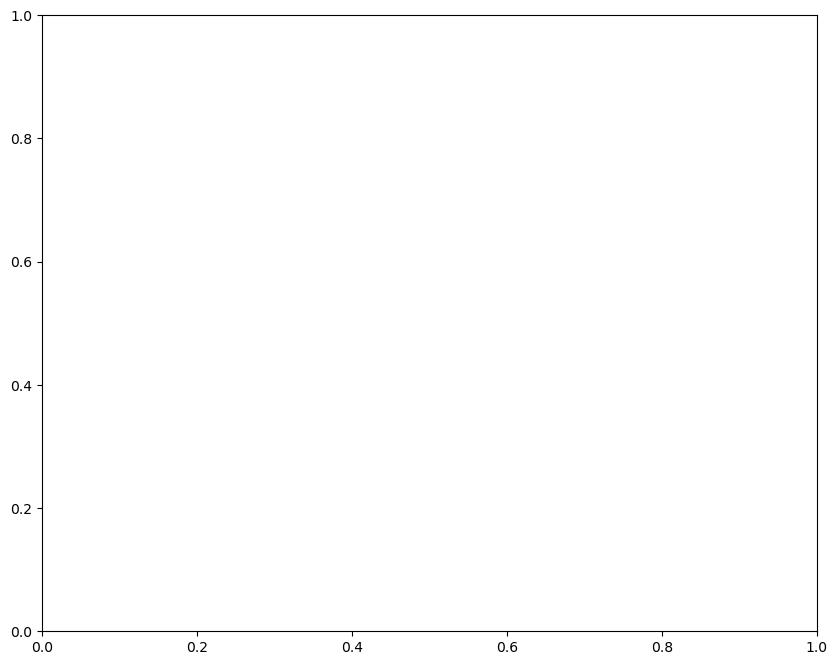

In [ ]:
# import shap
# import matplotlib.pyplot as plt

# # SHAP Values calculation
# explainer = shap.TreeExplainer(lgb_model_f1_st)
# shap_values = explainer.shap_values(X_train)
# if isinstance(shap_values, list) and len(shap_values) > 1:
#     shap_values_to_plot = shap_values[1] # 이진 분류의 양성 클래스(1)에 대한 SHAP 값
# else:
#     shap_values_to_plot = shap_values    # 회귀 또는 단일 클래스 SHAP 값

# plt.rcParams['axes.unicode_minus'] = False
# fig, ax = plt.subplots(figsize=(10, 8)) 
# fig.set_facecolor('white')

# # Plotting SHAP Dependence plot
# shap.dependence_plot(
#     'amt',                            # SHAP dependence plot을 그릴 메인 특성
#     shap_values_to_plot,              # 계산된 SHAP 값
#     X_train,                          # 원본 데이터 (특성 값의 분포를 위해 필요)
#     feature_names=X_train.columns,    # 특성 이름 (DataFrame의 columns 사용)
#     ax=ax,
#     cmap='viridis',                   # 색상 맵 (선택 사항, 'viridis', 'plasma', 'bwr' 등)
#     interaction_index='auto'          # 'auto': SHAP이 최적의 상호작용 특성을 찾음!
# )

# ax.set_title("SHAP Dependence Plot for 'amt'", fontsize=16) 
# plt.tight_layout()
# plt.show()

## 3. 개별 데이터 지정하여 피처의 영향력 확인

### SHAP Waterfall plot

In [ ]:
# # TreeExplainer for generating SHAP values
# explainer = shap.TreeExplainer(lgb_model_f1_st)
# shap_values = explainer.shap_values(X_test)

# # Plotting SHAP force plot
# data_point = X_test.iloc[0]

# shap.initjs()
# shap.force_plot(explainer.expected_value, 
#                 shap_values[0], 
#                 data_point, 
#                 feature_names=X_test.columns,
#                 # matplotlib=True,  # waterfall이나 bar일때 사용!  
#                 )

# ax.set_title("SHAP Waterfall Plot: data X_test[0]", fontsize=16) 
# plt.tight_layout()
# plt.show()

<Figure size 640x480 with 0 Axes>

~~js 출력이 안되는 것도 문제지만~~ 헉 왜 forceplot이지 다시

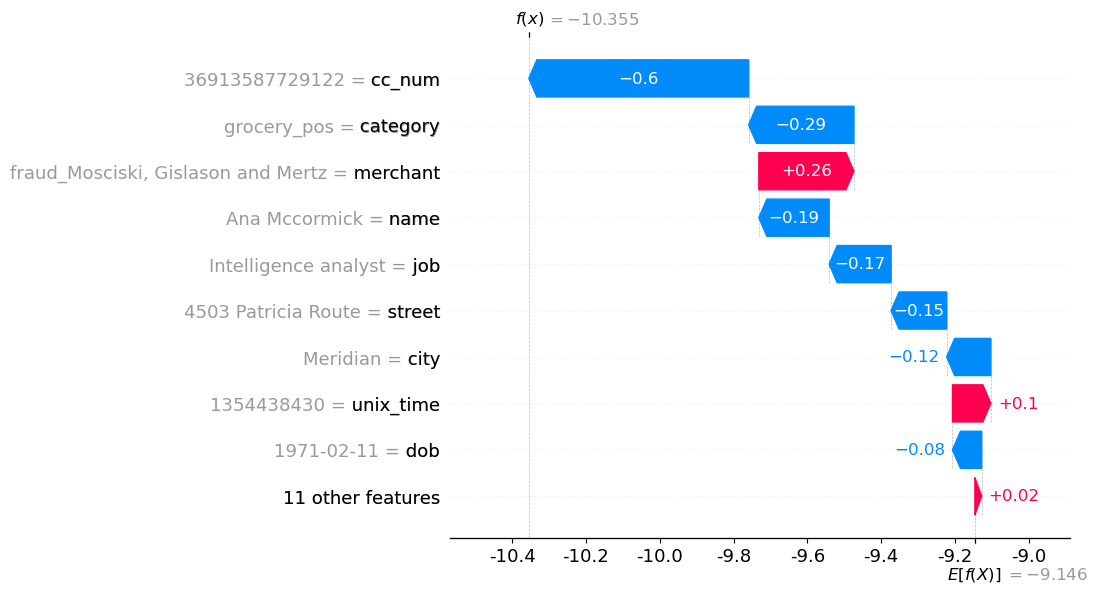

In [42]:
# SHAP
# explainer = shap.Explainer(lgb_model_f1_st)
shap_values = explainer(X_train)
shap.plots.waterfall(shap_values[0])

## 4. 의사결정 경로 시각화

- dtreeviz 활용
    - 그러나 LGBMClassifier의 경우 약한 트리를 앙상블하는 방식으로 단일 트리를 시각화하는데에 어려움이 있음
    - 개별 트리를 추출하여 시각화 하는 방식이 더욱 일반적
        - 따라서 `shap.TreeExplainer()`방식 사용하기로

In [ ]:
# import pandas as pd
# from sklearn.datasets import load_iris
# from sklearn.tree import DecisionTreeClassifier
# from dtreeviz.trees import dtreeviz


# viz = dtreeviz(lgb_model_f1_st,
#                X_test,
#                y_test,
#                feature_names=feature_names,
#                target_name='is_fraud', # 예측하려는 대상 변수의 이름
#                class_names=X_test.columns, # 타겟 클래스 이름
#                title="Decision Tree visualization",
#                orientation='TD' # Top-Down (위에서 아래로)
#               )

# # 시각화된 트리를 파일로 저장 (예: SVG, PNG)
# viz.save("lgb_tree.svg")

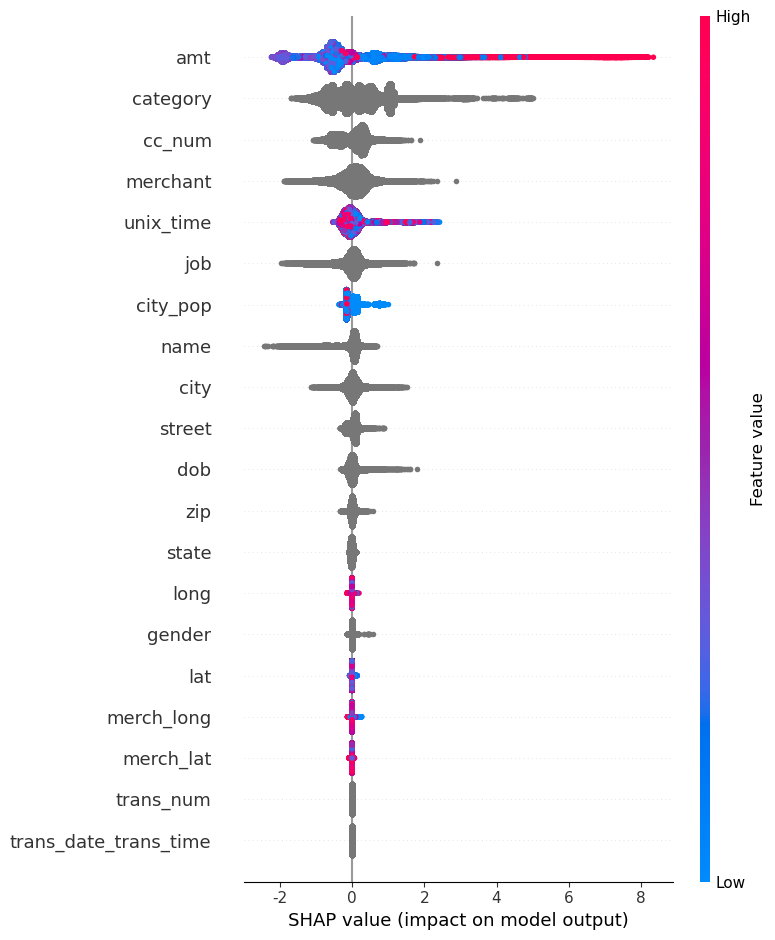

In [43]:
# shap.TreeExplainer() 사용 #

# LightGBM 모델을 직접 전달
explainer = shap.TreeExplainer(lgb_model_f1_st)

# SHAP 값 계산
# X_test 데이터에 대한 SHAP 값을 계산,  SHAP 값은 각 예측에 대한 각 특성의 기여도
shap_values = explainer.shap_values(X_test)

# SHAP summary plot (특성 중요도 및 영향 방향)
shap.summary_plot(shap_values, X_test, feature_names=X_test.columns)

# 특정 예측에 대한 force plot (개별 예측 설명)
shap.initjs() # Jupyter/IPython 환경에서 JavaScript 시각화를 위해 필요
shap.plots.force(explainer.expected_value, shap_values[0,:], X_test.iloc[0,:]) # 단일 예측에 대한 force plot